# Dari `type` Anonim Menjadi 3 Tier GrabCar

Notebook ini menjelaskan pendekatan transisi dari `type` anonim kompetisi menjadi tiga produk yang dapat dipilih pengguna: **GrabCar Hemat, Standard, dan Max**. Profil harga hanya dihitung dari train. Hasil akhirnya disimpan sebagai mapping tetap agar aplikasi tidak membutuhkan target harga dan tidak mengacak tier ketika inference.

> Catatan metodologi: clustering ini memang target-informed. Karena itu tier dipakai sebagai interpretasi produk dan kontrak deployment, bukan sebagai bukti bahwa cluster ditemukan tanpa supervisi.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
df = pd.read_csv(ROOT / 'data/train.csv')

price_by_type = (
    df.groupby('type', as_index=False)['price_mean']
      .agg(min='min', mean='mean', max='max')
      .sort_values('type')
)

display(price_by_type.head())

,type,min,mean,max
0,0,13.166667,16.760619,22.00
1,1,13.500000,16.606074,20.60
2,2,17.000000,21.087473,26.75
3,3,13.500000,20.632393,28.30
4,4,12.090909,19.168777,32.50


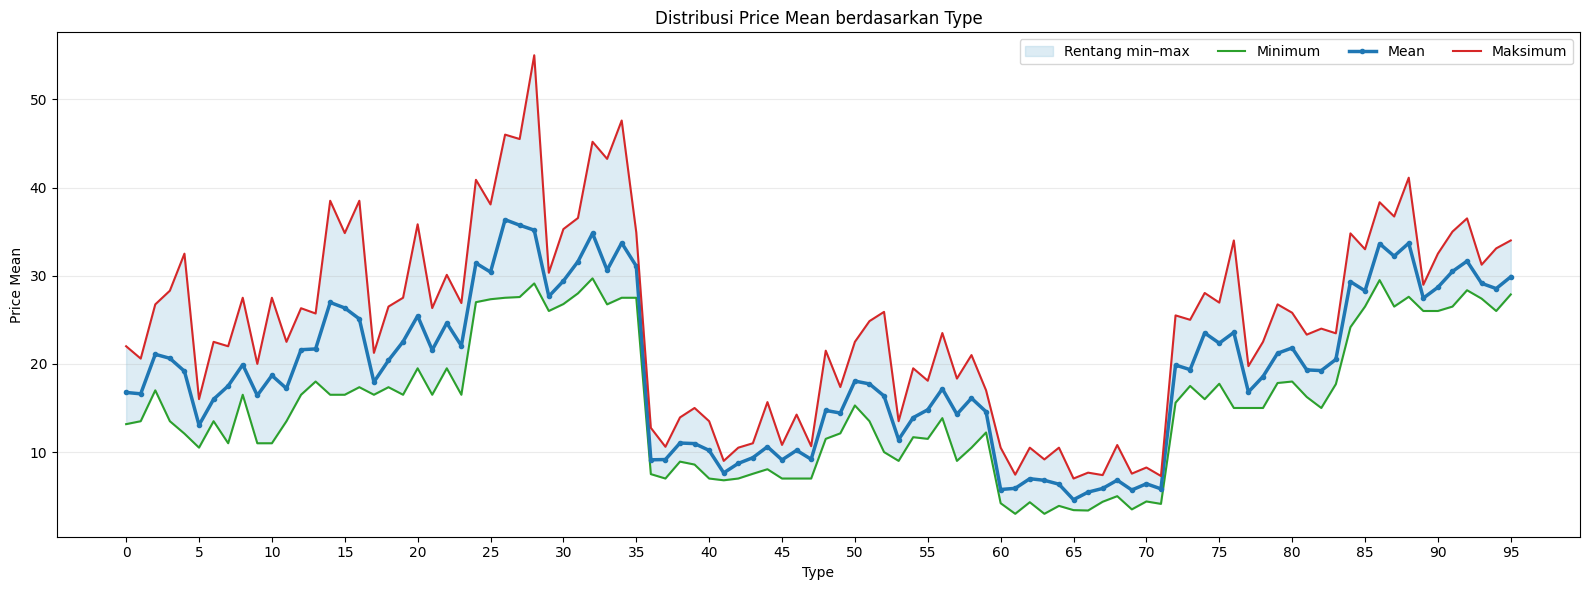

In [2]:
fig, ax = plt.subplots(figsize=(16, 6))

# Area min-max menunjukkan rentang distribusi setiap type.
ax.fill_between(
    price_by_type['type'],
    price_by_type['min'],
    price_by_type['max'],
    color='#9ecae1', alpha=0.35, label='Rentang min–max'
)
ax.plot(price_by_type['type'], price_by_type['min'],
        color='#2ca02c', linewidth=1.5, label='Minimum')
ax.plot(price_by_type['type'], price_by_type['mean'],
        color='#1f77b4', linewidth=2.5, marker='o', markersize=3, label='Mean')
ax.plot(price_by_type['type'], price_by_type['max'],
        color='#d62728', linewidth=1.5, label='Maksimum')

ax.set_title('Distribusi Price Mean berdasarkan Type')
ax.set_xlabel('Type')
ax.set_ylabel('Price Mean')
ax.set_xticks(price_by_type['type'][::5])
ax.grid(axis='y', alpha=0.25)
ax.legend(ncol=4)
plt.tight_layout()
plt.show()

## Membuat fitur cluster untuk `type`

Constraint bisnis mewajibkan tepat **3 cluster** dan eksperimen dibatasi pada **3 fitur distribusi**. Kombinasi `minimum`, `P10`, dan `P25` memisahkan batas harga dasar tiap `type` paling jelas pada silhouette score. Agglomerative clustering dengan Ward linkage dipakai karena jumlah `type` kecil dan kita ingin segmentasi bertingkat, bukan centroid yang harus dipakai untuk menebak request baru. Ketiga statistik dihitung hanya dari train lalu distandardisasi.

In [3]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Profil target per type, dibuat dari TRAIN saja.
type_profile = (
    df.groupby('type', as_index=False)['price_mean']
      .agg(price_mean_min='min',
           price_mean_p10=lambda s: s.quantile(.10),
           price_mean_p25=lambda s: s.quantile(.25))
)
cluster_features = [
    'price_mean_min', 'price_mean_p10', 'price_mean_p25'
]

scaler = StandardScaler()
X_type = scaler.fit_transform(type_profile[cluster_features])

N_CLUSTERS = 3
cluster_model = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage='ward')
type_profile['type_cluster_raw'] = cluster_model.fit_predict(X_type)
silhouette = silhouette_score(X_type, type_profile['type_cluster_raw'])

# Nomor cluster diurutkan dari cluster termurah ke termahal agar mudah dibaca.
cluster_order = (type_profile.groupby('type_cluster_raw')['price_mean_p25']
                 .mean().sort_values().index)
cluster_remap = {old: new for new, old in enumerate(cluster_order)}
type_profile['type_cluster'] = type_profile['type_cluster_raw'].map(cluster_remap)

print(f'Jumlah cluster: {N_CLUSTERS}')
print(f'Silhouette score: {silhouette:.6f}')
display(type_profile.sort_values(['type_cluster', 'price_mean_p25']))

Jumlah cluster: 3
Silhouette score: 0.660389


,type,price_mean_min,price_mean_p10,price_mean_p25,type_cluster_raw,type_cluster
65,65,3.416667,4.038462,4.333333,2,0
66,66,3.375000,4.837500,5.090241,2,0
69,69,3.500000,5.000000,5.327586,2,0
60,60,4.200000,5.017849,5.357143,2,0
67,67,4.366667,5.200833,5.500000,2,0
...,...,...,...,...,...,...
86,86,29.500000,32.000000,32.572917,1,2
28,28,29.125000,31.525000,33.126374,1,2
32,32,29.700000,32.333333,33.200000,1,2
27,27,27.583333,32.866667,33.849026,1,2


In [4]:
# Mapping migrasi dari type anonim kompetisi ke kontrak fitur production.
type_cluster_mapping = type_profile[['type', 'type_cluster']].copy()
type_cluster_mapping['service_tier_id'] = type_cluster_mapping['type_cluster'] + 1
tier_names = {
    1: 'GrabCar Hemat',
    2: 'GrabCar Standard',
    3: 'GrabCar Max',
}
type_cluster_mapping['service_tier'] = (
    type_cluster_mapping['service_tier_id'].map(tier_names)
)
train_featured = df.merge(type_cluster_mapping, on='type', how='left', validate='many_to_one')
test = pd.read_csv(ROOT / 'data/test.csv')
test_featured = test.merge(type_cluster_mapping, on='type', how='left', validate='many_to_one')

# Type baru yang tidak pernah ada di train mendapat cluster -1.
train_featured['service_tier_id'] = train_featured['service_tier_id'].fillna(0).astype(int)
test_featured['service_tier_id'] = test_featured['service_tier_id'].fillna(0).astype(int)

type_cluster_mapping.to_csv(ROOT / 'artifacts/type_cluster_mapping.csv', index=False)
print('Mapping tersimpan: artifacts/type_cluster_mapping.csv')
print('Missing tier di train:', (train_featured['service_tier_id'] == 0).sum())
print('Missing tier di test :', (test_featured['service_tier_id'] == 0).sum())
display(type_cluster_mapping.sort_values(['service_tier_id', 'type']))

Mapping tersimpan: artifacts/type_cluster_mapping.csv
Missing tier di train: 0
Missing tier di test : 0


,type,type_cluster,service_tier_id,service_tier
36,36,0,1,GrabCar Hemat
37,37,0,1,GrabCar Hemat
38,38,0,1,GrabCar Hemat
39,39,0,1,GrabCar Hemat
40,40,0,1,GrabCar Hemat
...,...,...,...,...
91,91,2,3,GrabCar Max
92,92,2,3,GrabCar Max
93,93,2,3,GrabCar Max
94,94,2,3,GrabCar Max


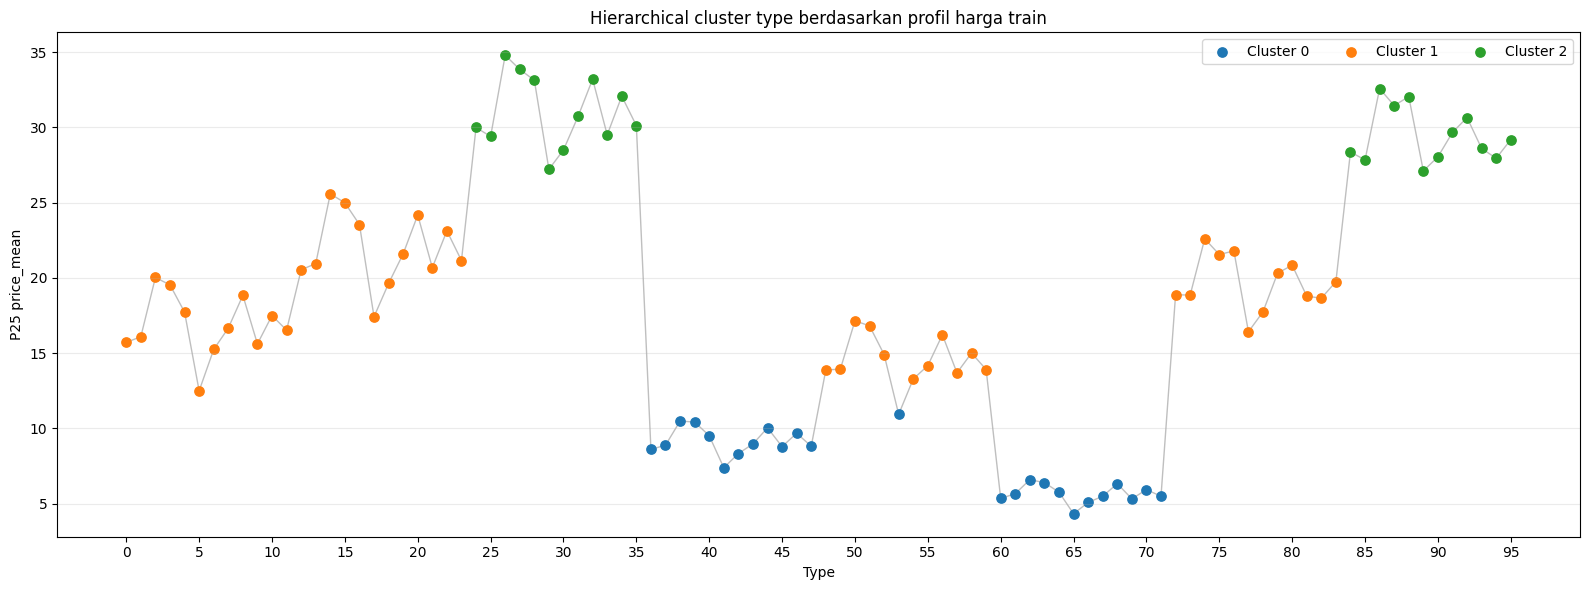

In [5]:
fig, ax = plt.subplots(figsize=(16, 6))
for cluster, part in type_profile.sort_values('type').groupby('type_cluster'):
    ax.scatter(part['type'], part['price_mean_p25'], s=45, label=f'Cluster {cluster}')
ax.plot(type_profile['type'], type_profile['price_mean_p25'],
        color='0.75', linewidth=1, zorder=0)
ax.set(title='Hierarchical cluster type berdasarkan profil harga train',
       xlabel='Type', ylabel='P25 price_mean')
ax.set_xticks(type_profile['type'][::5])
ax.grid(axis='y', alpha=.25)
ax.legend(ncol=4)
plt.tight_layout()
plt.show()